In [1]:
#libraries and dirrectory 
import pandas as pd
import numpy as np
import os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import curve_fit
import patientFunctions as ptfn
import seaborn as sns
import matplotlib.pyplot as plt
import re
import matplotlib.patches as mpatches
from collections import Counter



#directory

# machine_directory = 'C:/Users/mcremer' #the C and path to the project folder
machine_directory = 'C:/Users/maega' #when working from home machine
storage_directory = 'UFL Dropbox/Maegan Cremer/research-share/Maegan/Projects' #Local, HPG, or dropbox
project_directory = 'Cardiac-Amyloidosis-Multiple-Myeloma' #project folder
project_lv2_directory = '019_1_Mistic_ClinicalSplit_CodeOcean' #deeper part of project folder

path = os.path.join(machine_directory, storage_directory, 
                    project_directory, project_lv2_directory)

# parent_dir = path
outputDir = path
os.chdir(outputDir)

In [2]:
#outputs
folderNameHeader = "FeatListCompare_"
folderNameCommon = ""
folderNameSuffix = "_2025-08"

# fileNameHeader_1 = "DF_SelectedFeats_"
# # fileNameHeader_2 = "ALUnknownPts"
# # fileNameCommon = "_Features"
fileNameSuffix = "_2025-08"

folder_data_out = ptfn.makeFolderPathForData(parent_dir=outputDir, folderName_header=folderNameHeader, 
                                        folderName_common=folderNameCommon, folderName_suffix=folderNameSuffix)


folderNameOut = folder_data_out

In [3]:
#model dictionary construction
modelNames = ['EchoAdj', 'DescOnly', 'ParamsOnly', 'DescFits']
modelNames_dict = {'EchoAdj': 'EchoAdj',
                   'DescOnly': 'DescOnly',
                   'ParamsOnly': 'ParamsOnly',
                   'DescFits': 'DescFits'}

# first round feature selection

In [4]:
#import files for list of features
selectedFeaturesFolder = os.path.join(outputDir, "DF_SelectedFeats_First" )

#directory for where selected features are stored
FilesInFolder = os.listdir(selectedFeaturesFolder)


#dictionary of selected features
dict_selected_feats = {}

dict_feats_origData = {} #original data section of the feature
dict_feats_transforms = {} #for the transformations applied to the original data

dict_dataimport_all = {}
dict_dataimport_positive={}
dict_dataimport_negative = {}

#import each file in that directory to a pandas object 
for model in modelNames: 
    for fileName in FilesInFolder:
        if model in fileName:
            #import the data as pandas
            featuresData = pd.read_excel(os.path.join(selectedFeaturesFolder, fileName), sheet_name = 'all')
            dict_dataimport_all[model] = featuresData
            #get only the header row
            featuresList = featuresData.columns[1:]
            #add the features list to dictionary with the model as the key
            dict_selected_feats[model] = featuresList

            #parsing the featurs into the first and second part
            ogData_temp = [feature.split('_')[0] for feature in featuresList]
            transforms_temp = [" ".join(feature.split('_')[1:]) for feature in featuresList]

            dict_feats_origData[model] = ogData_temp
            dict_feats_transforms[model] = transforms_temp

            featuresDataPositive = pd.read_excel(os.path.join(selectedFeaturesFolder, fileName), sheet_name = 'positive')
            dict_dataimport_positive[model] = featuresDataPositive
            featuresDataNegative = pd.read_excel(os.path.join(selectedFeaturesFolder, fileName), sheet_name = 'negative')
            dict_dataimport_negative[model] = featuresDataNegative


In [5]:
#get count information for features, original data, and tranformations
i = 0
for model in modelNames:
    # selected_feats = dict_selected_feats[model]
    count_selectedFeats_model = pd.DataFrame.from_dict(Counter(dict_selected_feats[model]), orient = 'index')
    count_orgData_model = pd.DataFrame.from_dict(Counter(dict_feats_origData[model]), orient = 'index')
    count_transforms_model = pd.DataFrame.from_dict(Counter(dict_feats_transforms[model]), orient = 'index')
    if i == 0: 
        count_selectedFeats = count_selectedFeats_model
        count_orgData= count_orgData_model
        count_transforms = count_transforms_model
    else: 
        count_selectedFeats= pd.concat([count_selectedFeats, count_selectedFeats_model], axis= 1)
        count_orgData = pd.concat([count_orgData, count_orgData_model], axis= 1)
        count_transforms = pd.concat([count_transforms, count_transforms_model], axis = 1)
    i = i+1

count_selectedFeats.columns = modelNames
count_orgData.columns = modelNames
count_transforms.columns = modelNames


# second round feature selection

In [6]:
#import files for list of features
selectedFeaturesFolder = os.path.join(outputDir, "DF_SelectedFeats_Second" )

#directory for where selected features are stored
FilesInFolder = os.listdir(selectedFeaturesFolder)


#dictionary of selected features
dict_selected_feats_second = {}

dict_feats_second_origData = {} #original data section of the feature
dict_feats_second_transforms = {} #for the transformations applied to the original data

#saving imported data
dict_dataimport_all_second = {}

dict_dataimport_positive_second={}
dict_dataimport_negative_second = {}


#import each file in that directory to a pandas object 
for model in modelNames: 
    for fileName in FilesInFolder:
        if model in fileName:
            #import the data as pandas
            featuresData = pd.read_excel(os.path.join(selectedFeaturesFolder, fileName), sheet_name = 'all')
            dict_dataimport_all_second[model] = featuresData
            #get only the header row
            featuresList = featuresData.columns[1:]
            #add the features list to dictionary with the model as the key
            dict_selected_feats_second[model] = featuresList

            #parsing the featurs into the first and second part
            ogData_temp = [feature.split('_')[0] for feature in featuresList]
            transforms_temp = [" ".join(feature.split('_')[1:]) for feature in featuresList]

            dict_feats_second_origData[model] = ogData_temp
            dict_feats_second_transforms[model] = transforms_temp

            featuresDataPositive = pd.read_excel(os.path.join(selectedFeaturesFolder, fileName), sheet_name = 'positive')
            dict_dataimport_positive_second[model] = featuresDataPositive
            featuresDataNegative = pd.read_excel(os.path.join(selectedFeaturesFolder, fileName), sheet_name = 'negative')
            dict_dataimport_negative_second[model] = featuresDataNegative




In [7]:
#get count information for features, original data, and tranformations
i = 0
for model in modelNames:
    count_selectedFeats_model = pd.DataFrame.from_dict(Counter(dict_selected_feats_second[model]), orient = 'index')
    count_orgData_model = pd.DataFrame.from_dict(Counter(dict_feats_second_origData[model]), orient = 'index')
    count_transforms_model = pd.DataFrame.from_dict(Counter(dict_feats_second_transforms[model]), orient = 'index')
    if i == 0: 
        count_selectedFeats_second = count_selectedFeats_model
        count_orgData_second = count_orgData_model
        count_transforms_second = count_transforms_model
    else: 
        count_selectedFeats_second= pd.concat([count_selectedFeats_second, count_selectedFeats_model], axis= 1)
        count_orgData_second = pd.concat([count_orgData_second, count_orgData_model], axis= 1)
        count_transforms_second = pd.concat([count_transforms_second, count_transforms_model], axis = 1)
    i = i+1

count_selectedFeats_second.columns = modelNames
count_orgData_second.columns = modelNames
count_transforms_second.columns = modelNames


# frequency of original data

In [8]:
#import file for frequency of original data

# visualization first round feature selection

## frequency of features

In [9]:
#heatmap for original data across models
cmap = 'magma_r'

<Axes: >

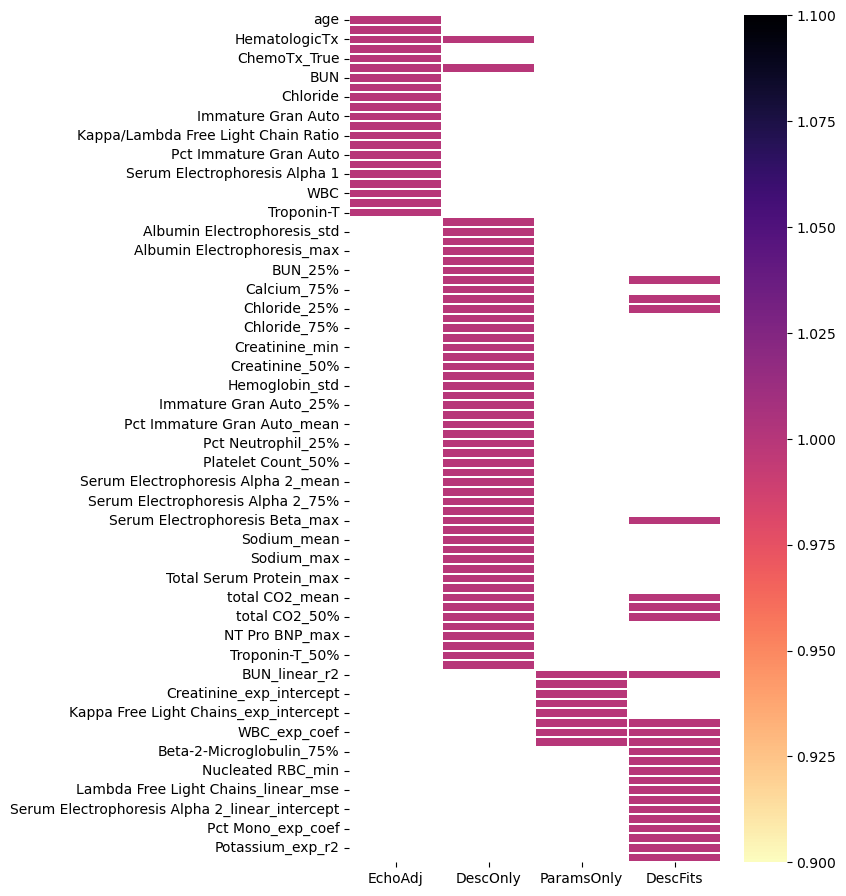

In [10]:
#plotting heatmap for feature frequency across models
fig, ax = plt.subplots(figsize = (6,11))
sns.heatmap(count_selectedFeats, cmap = cmap, ax = ax, linewidths=0.1)

Text(0.5, 1.0, 'Frequency of Data Characteristic')

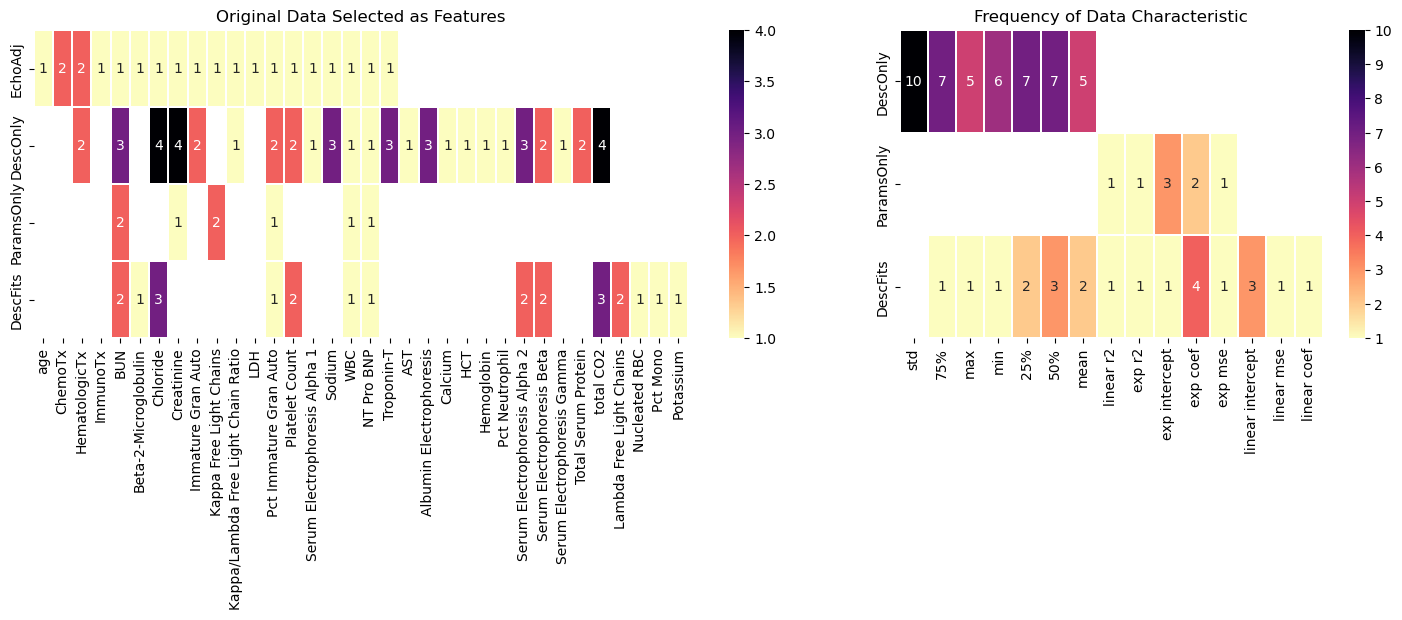

In [11]:
#heatmap for orignial data and transformation frequency across models
fig= plt.figure(figsize = (18,4))
ax1 = plt.subplot2grid((1, 5), (0,0), colspan = 3)
sns.heatmap(count_orgData.T, ax=ax1, cmap = cmap, linewidths=0.1, annot= True)
ax1.set_title("Original Data Selected as Features")
ax2 = plt.subplot2grid((1, 5), (0,3), colspan=2)
sns.heatmap(count_transforms.iloc[2:].T.iloc[1:], ax=ax2, cmap = cmap, linewidths=0.1, annot = True)
ax2.set_title("Frequency of Data Characteristic")

<Axes: >

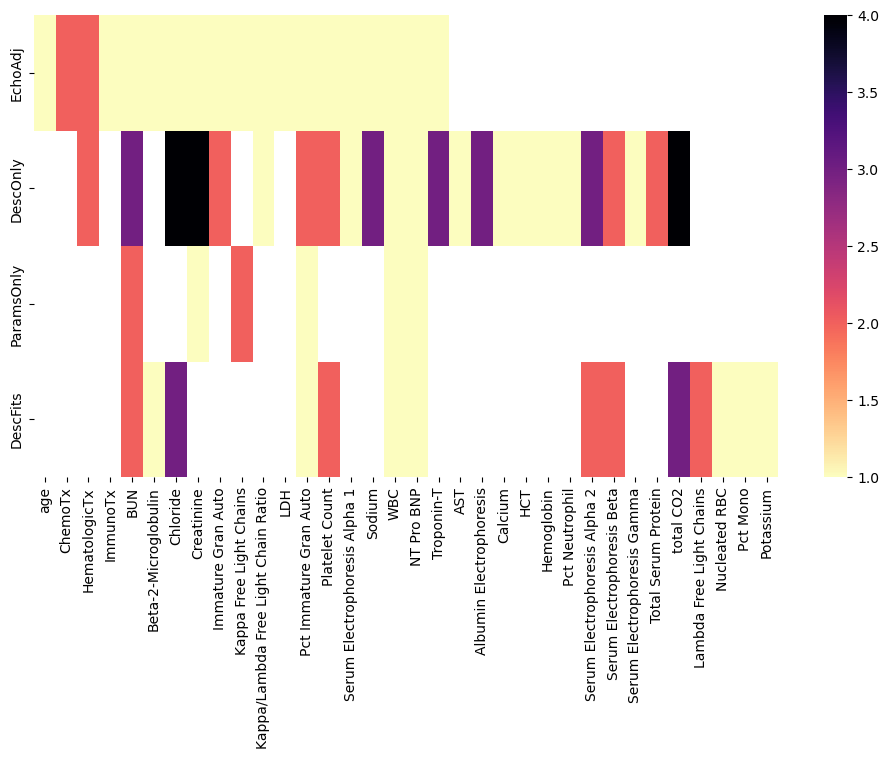

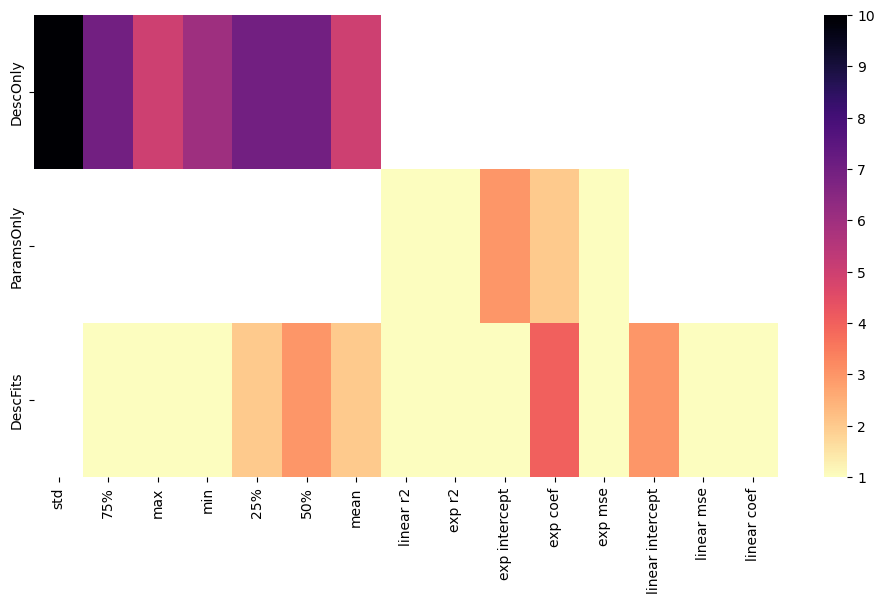

In [12]:
fig, ax = plt.subplots(figsize = (12,6))
sns.heatmap(count_orgData.T, ax=ax, cmap = cmap)
fig, ax2 = plt.subplots(figsize = (12,6))
sns.heatmap(count_transforms.iloc[2:].T.iloc[1:], ax=ax2, cmap = cmap)

In [13]:
dict_dataimport_all['DescFits'].iloc[:,1:]

,BUN_50%,Beta-2-Microglobulin_75%,Chloride_mean,Chloride_25%,Lambda Free Light Chains_50%,Nucleated RBC_min,Serum Electrophoresis Beta_max,total CO2_mean,total CO2_25%,total CO2_50%,...,Platelet Count_linear_coef,Serum Electrophoresis Alpha 2_linear_intercept,Serum Electrophoresis Beta_linear_intercept,Pct Immature Gran Auto_exp_mse,Pct Mono_exp_coef,Platelet Count_exp_coef,Potassium_exp_r2,Serum Electrophoresis Alpha 2_exp_coef,WBC_exp_coef,NT Pro BNP_exp_intercept
0,19.5,18.100,101.900000,100.25,1041.500,0.00,0.6,26.400000,26.00,26.5,...,-0.458076,0.814868,0.561959,6.673658e-03,0.001285,-0.002584,0.150139,-0.000077,-0.002440,6.245677
1,35.0,10.550,105.000000,100.50,36.430,0.00,1.0,23.250000,19.00,23.0,...,-0.803796,1.247752,0.881436,2.152999e-02,0.001303,-0.001449,0.255786,-0.000291,-0.000405,8.951901
2,38.0,18.250,99.744681,94.00,24.890,0.00,7.0,24.985816,22.00,24.0,...,0.009523,0.766314,1.143419,1.493546e-01,0.000241,0.000201,0.010828,-0.000002,-0.000059,5.995790
3,31.0,6.225,99.000000,98.00,44.575,0.02,0.7,20.500000,20.00,20.5,...,0.246034,1.409736,0.444931,2.187710e-02,0.000029,0.001034,0.059980,-0.000107,-0.000219,8.267514
4,25.5,3.800,103.250000,102.00,12.160,0.00,0.9,26.125000,25.75,27.0,...,0.108012,0.606625,0.971676,2.752140e-02,-0.000672,0.000468,0.104033,0.000080,0.000404,9.097141
5,44.0,10.275,96.984496,94.00,76.840,0.00,1.0,28.434109,26.00,28.0,...,-0.086344,1.308065,0.707881,3.328802e-02,-0.000147,-0.000209,0.017377,-0.000026,0.000500,8.451165
6,13.5,5.000,102.300000,99.75,19.420,0.00,1.0,28.016667,26.75,28.0,...,-0.075399,1.526964,0.593847,5.672410e-02,0.000244,-0.000324,0.078775,-0.000294,-0.000730,6.775088
7,20.0,2.825,105.454545,104.25,13.170,0.00,14.0,24.681818,23.00,24.0,...,-1.102833,23.986624,14.991678,4.568548e-01,0.000813,-0.009229,0.000812,-0.012700,-0.003737,5.665584
8,28.0,2.575,97.200000,96.25,8.780,0.00,0.8,27.900000,27.25,28.5,...,0.019752,0.828462,0.728462,8.217030e-03,-0.000026,0.000060,0.004929,-0.000020,-0.000726,8.795142
9,62.5,9.250,106.000000,105.00,35.065,0.00,1.5,22.000000,21.00,22.0,...,-0.172753,0.815142,0.988453,1.420717e-02,0.000813,-0.001063,0.004727,-0.000131,-0.000699,9.252729


## correlation plots by model

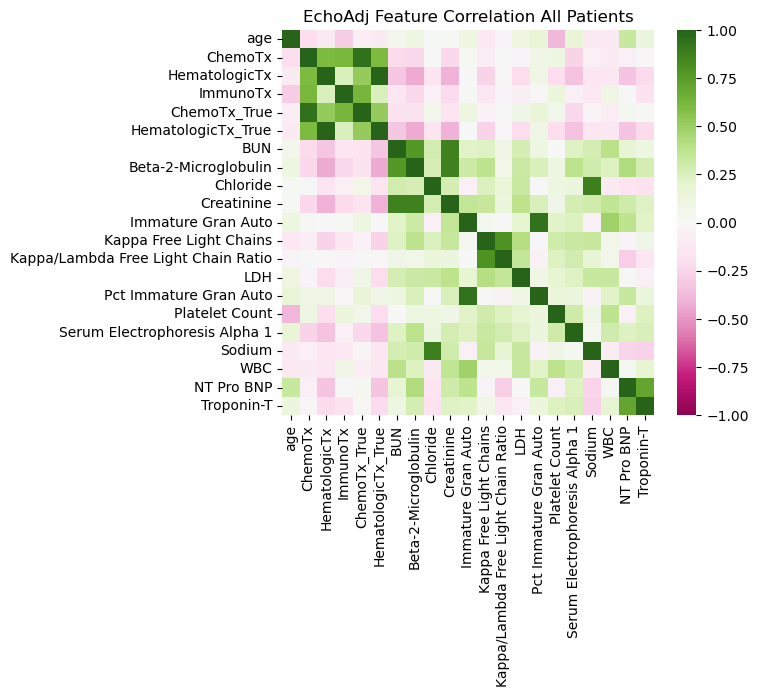

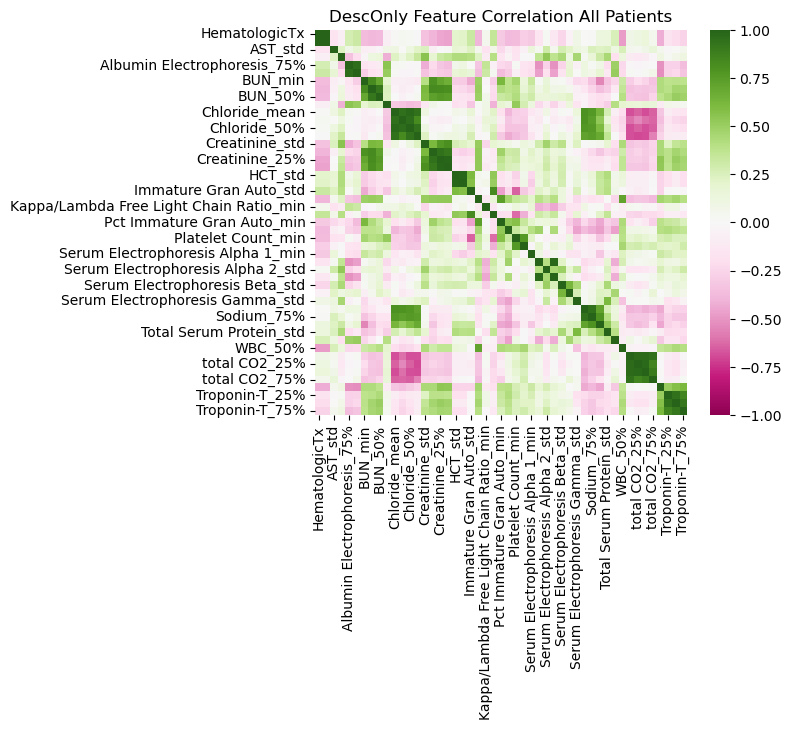

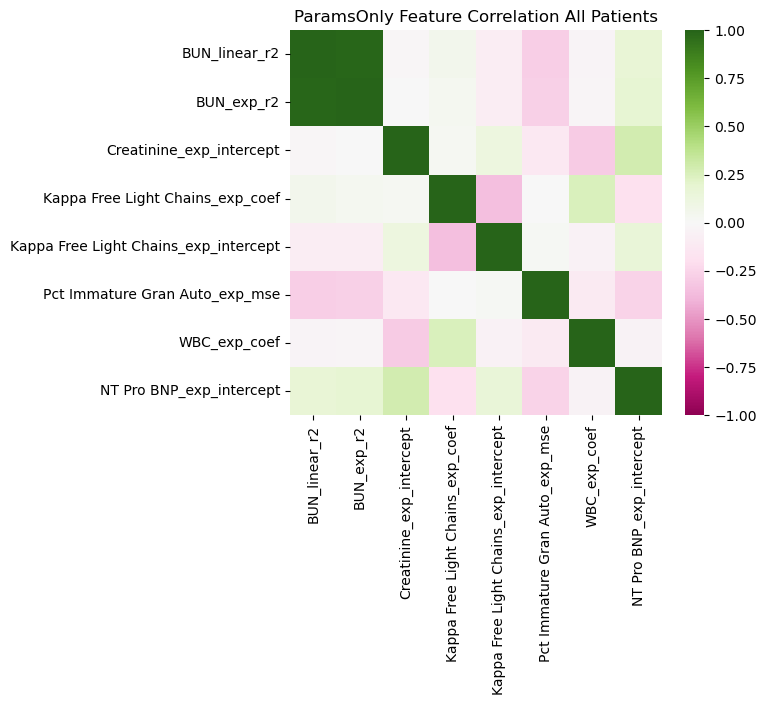

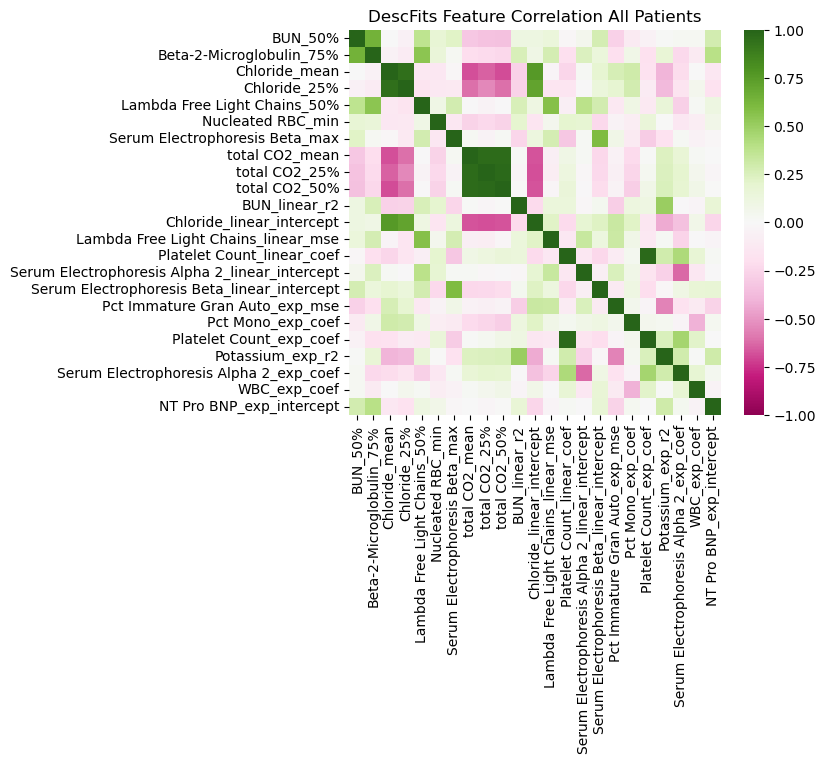

In [14]:
# correlation map of only the selected features
for model in modelNames:
    fig, ax = plt.subplots(figsize= (6,5))
    feature_corr = dict_dataimport_all[model].iloc[:,1:].corr(method = 'spearman')
    sns.heatmap(feature_corr, cmap = "PiYG", vmin =-1, vmax = 1, center = 0, annot = False, ax= ax)
    plt.title(str(model)+ " Feature Correlation All Patients")


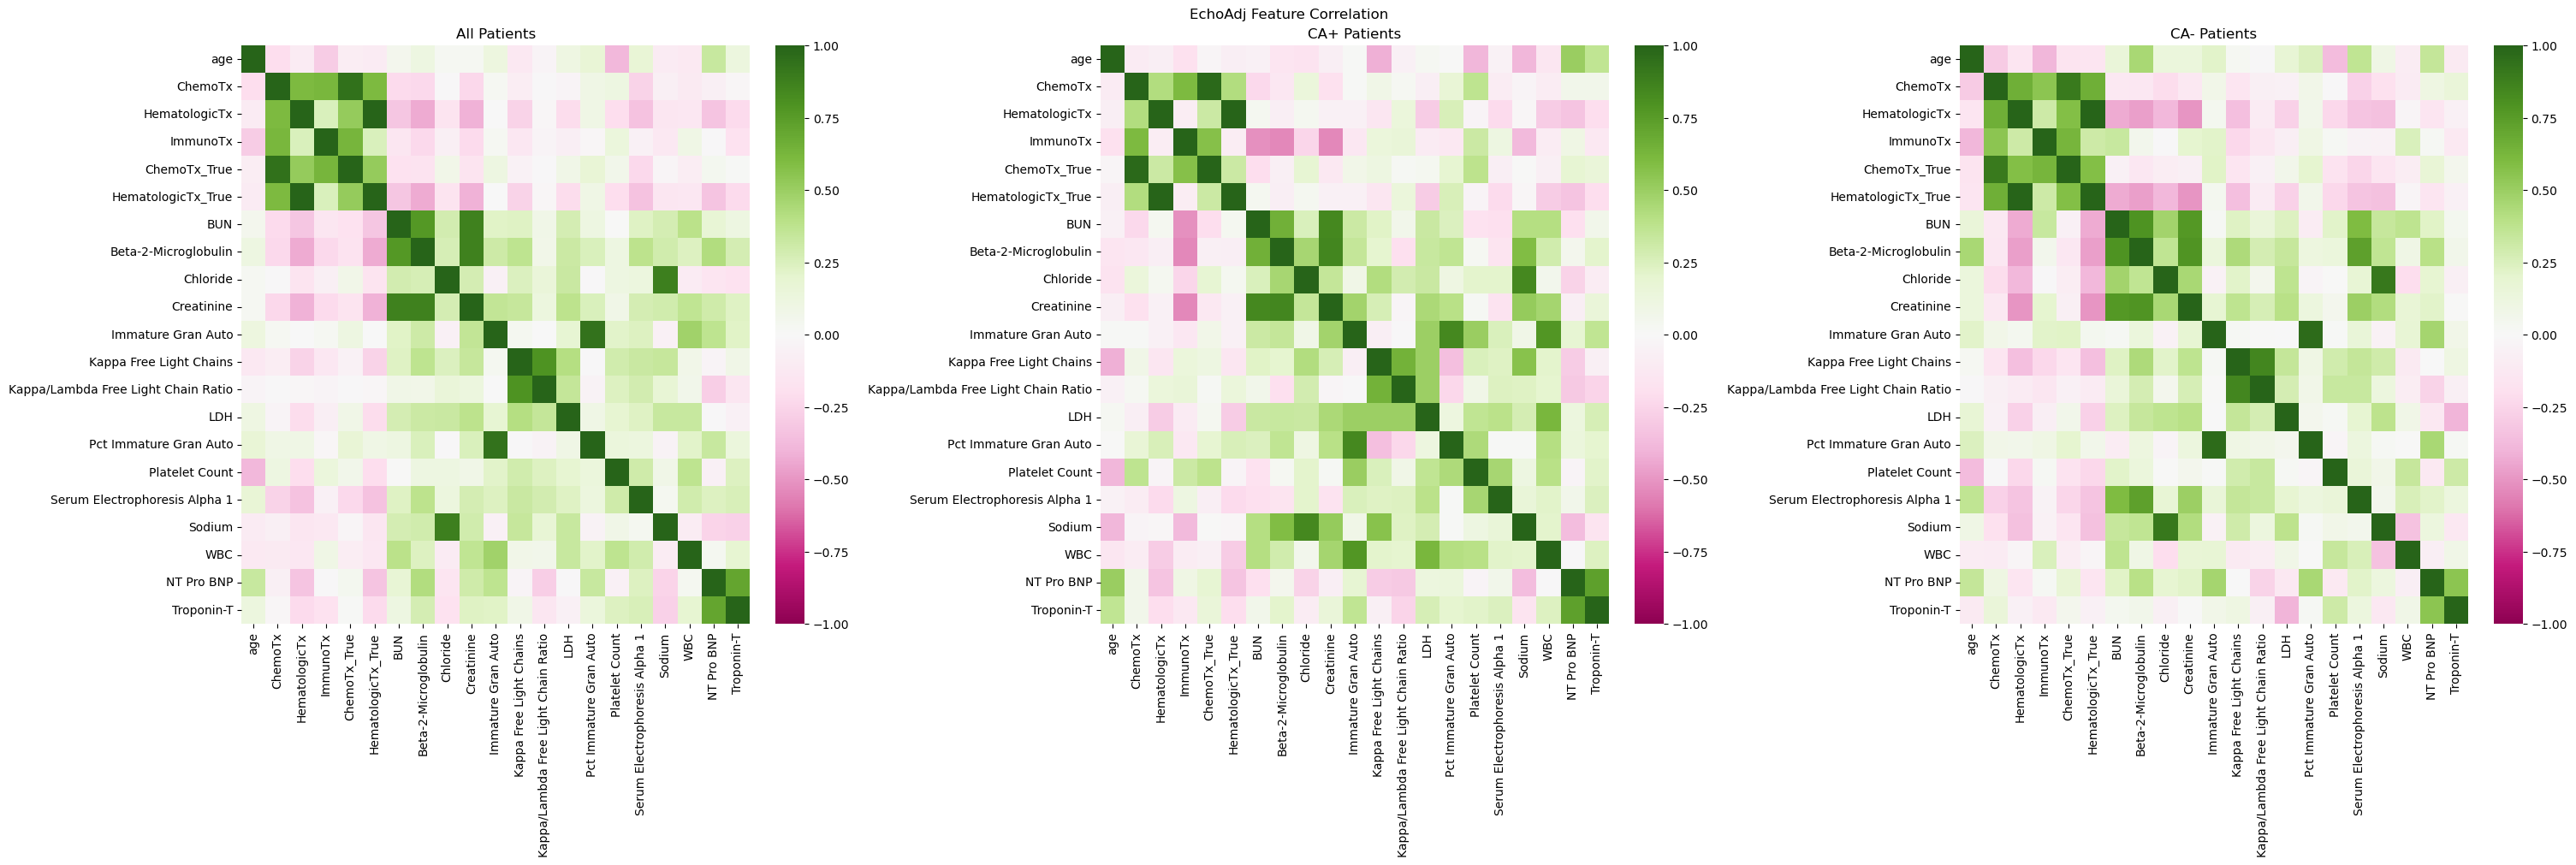

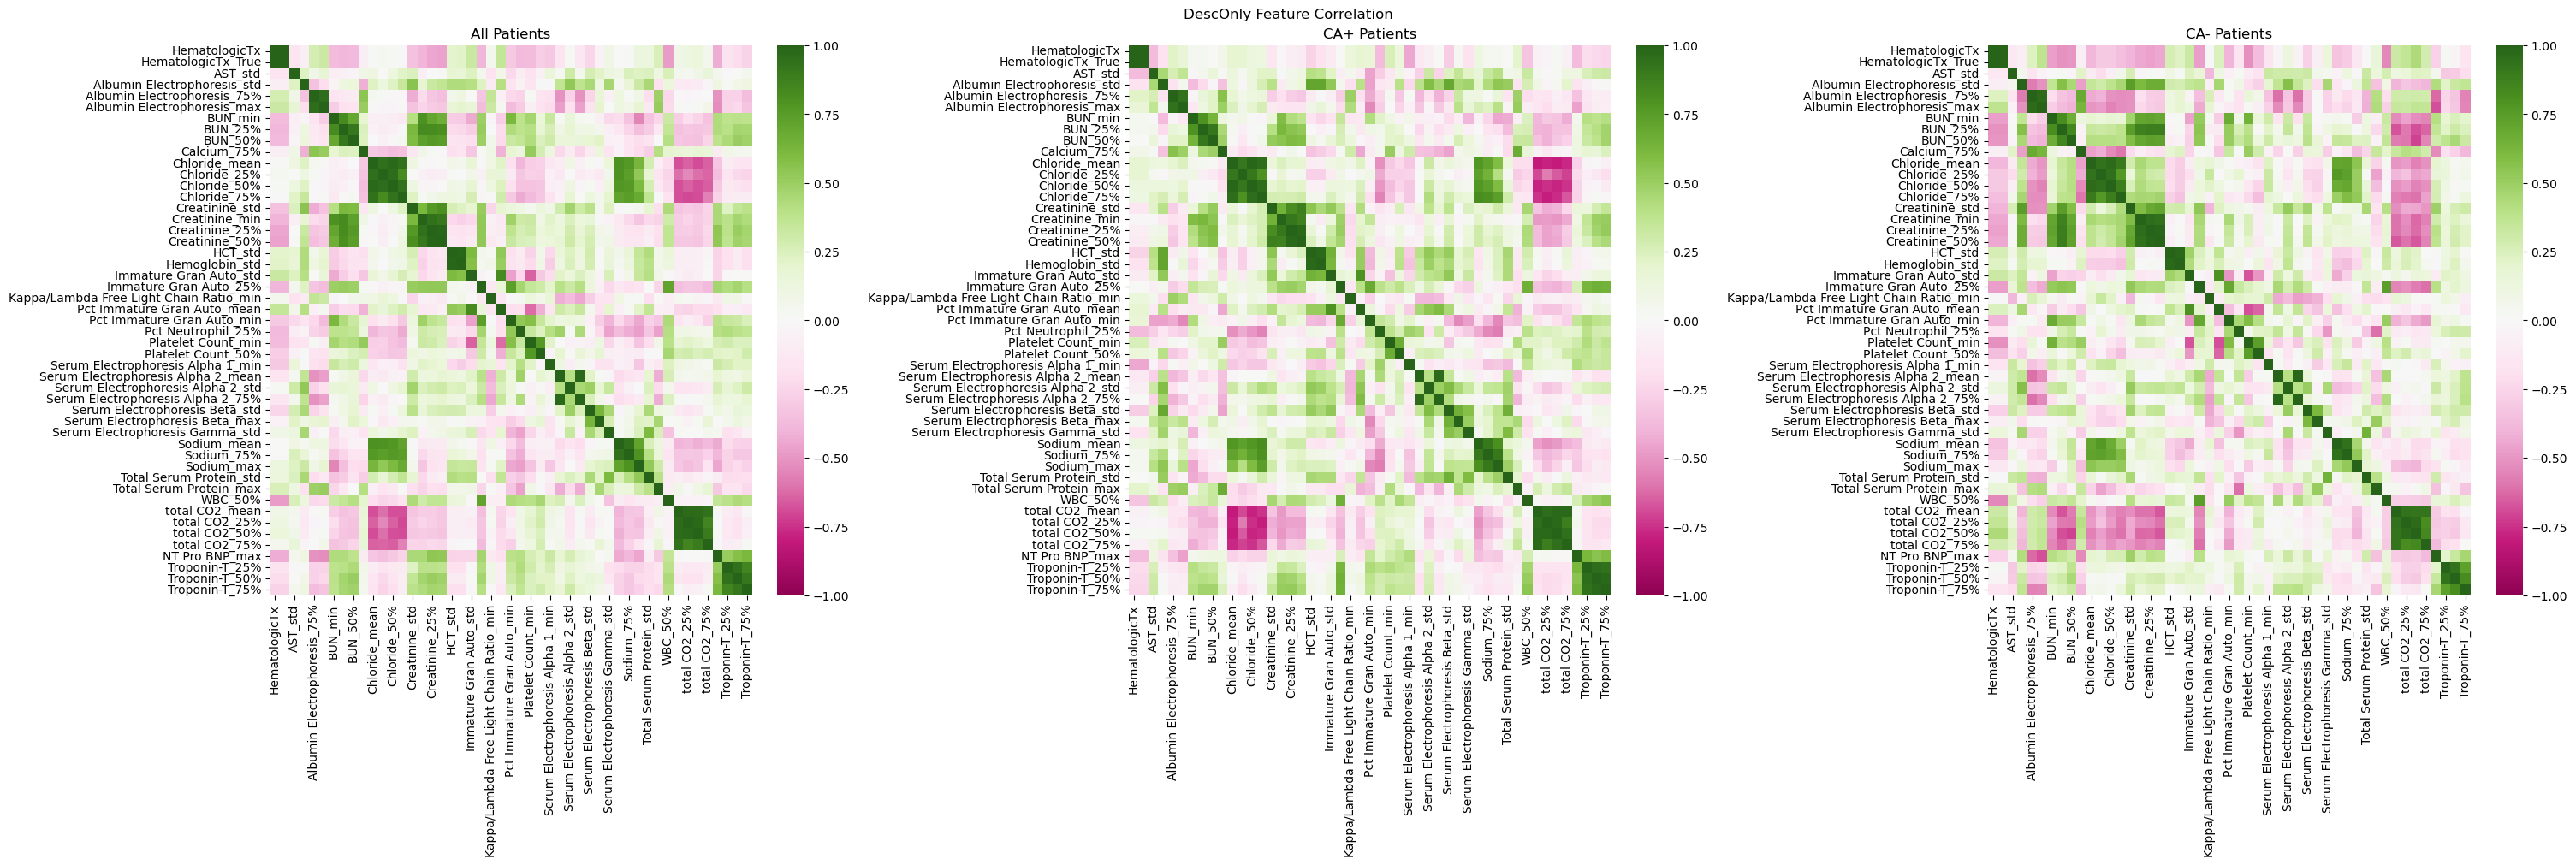

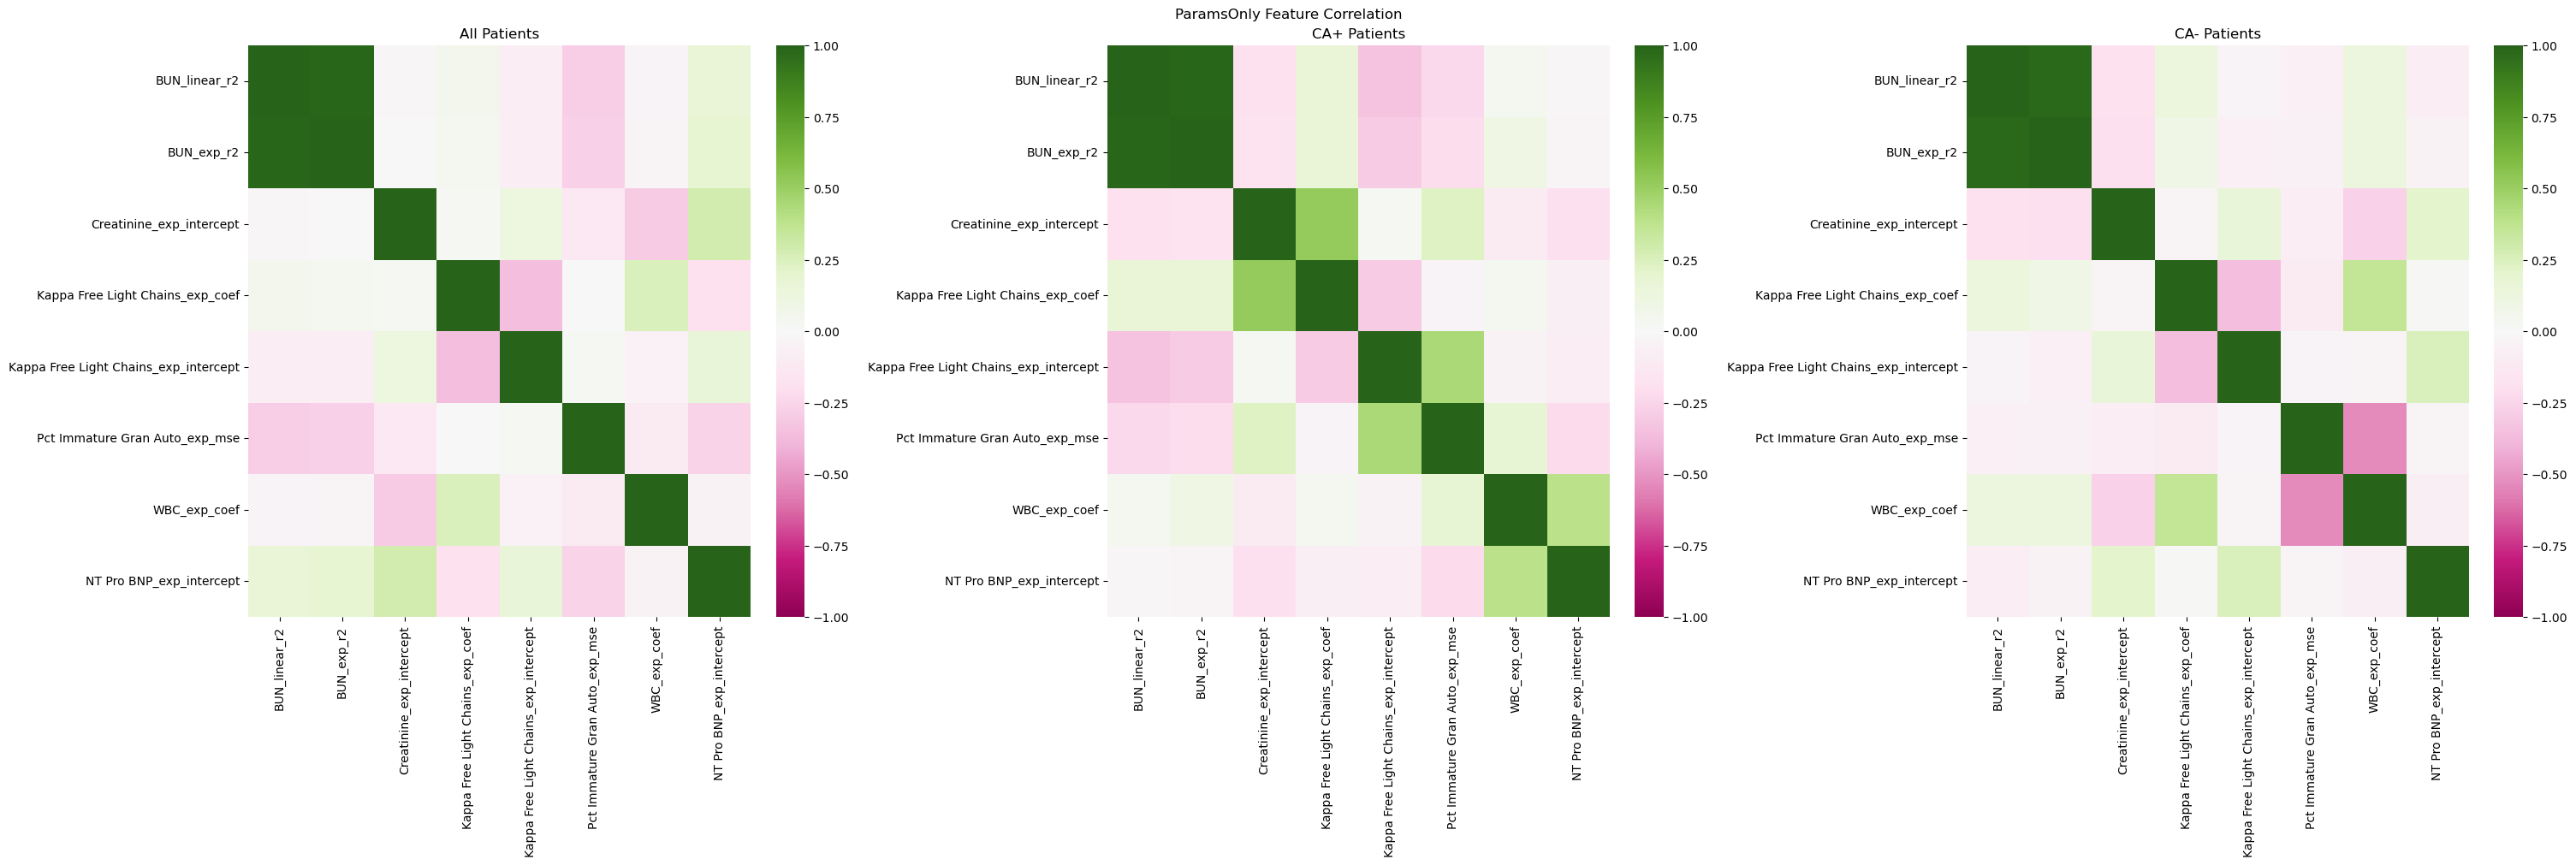

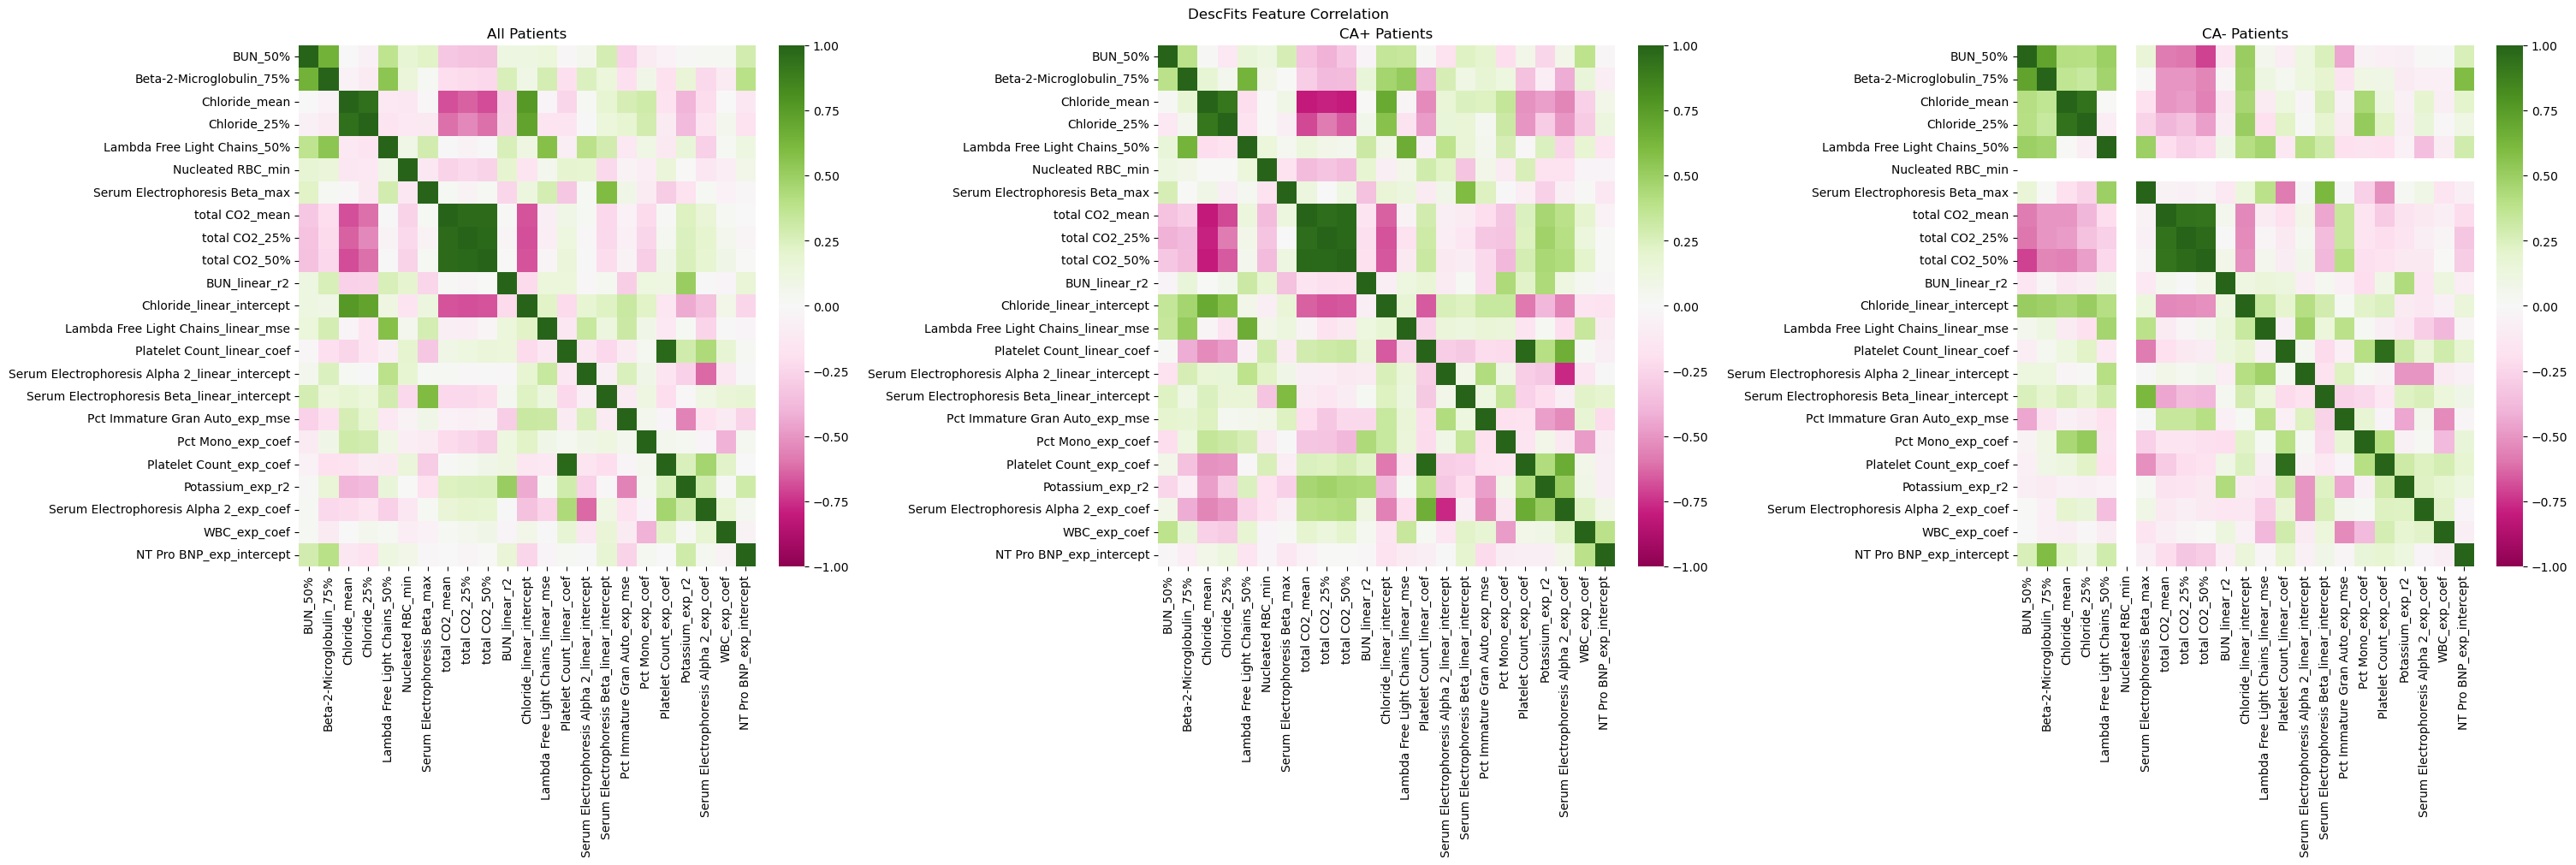

In [15]:
# correlation map of only the selected features
for model in modelNames:
    fig= plt.figure(figsize = (30,10), layout ='constrained')
    fig.suptitle(str(model)+ " Feature Correlation")
    ax1 = plt.subplot2grid((1, 3), (0,0))
    feature_corr = dict_dataimport_all[model].iloc[:,1:].corr(method = 'spearman')
    sns.heatmap(feature_corr, cmap = "PiYG", vmin =-1, vmax = 1, center = 0, annot = False, ax= ax1)
    ax1.set_title("All Patients")

    ax2 = plt.subplot2grid((1, 3), (0,1))
    feature_corr = dict_dataimport_positive[model].iloc[:,1:].corr(method = 'spearman')
    sns.heatmap(feature_corr, cmap = "PiYG", vmin =-1, vmax = 1, center = 0, annot = False, ax= ax2)
    ax2.set_title("CA+ Patients")

    ax3 = plt.subplot2grid((1, 3), (0,2))
    feature_corr = dict_dataimport_negative[model].iloc[:,1:].corr(method = 'spearman')
    sns.heatmap(feature_corr, cmap = "PiYG", vmin =-1, vmax = 1, center = 0, annot = False, ax= ax3)
    ax3.set_title("CA- Patients")

    



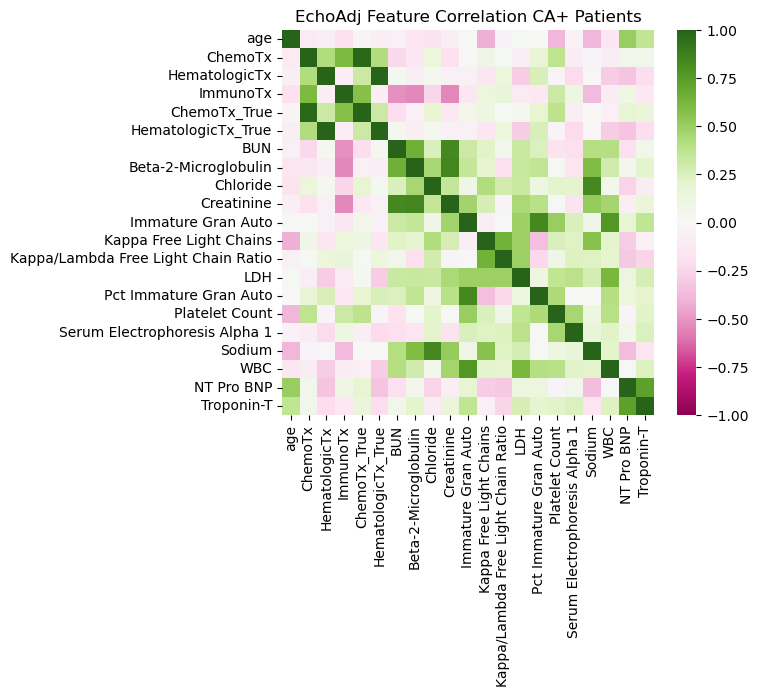

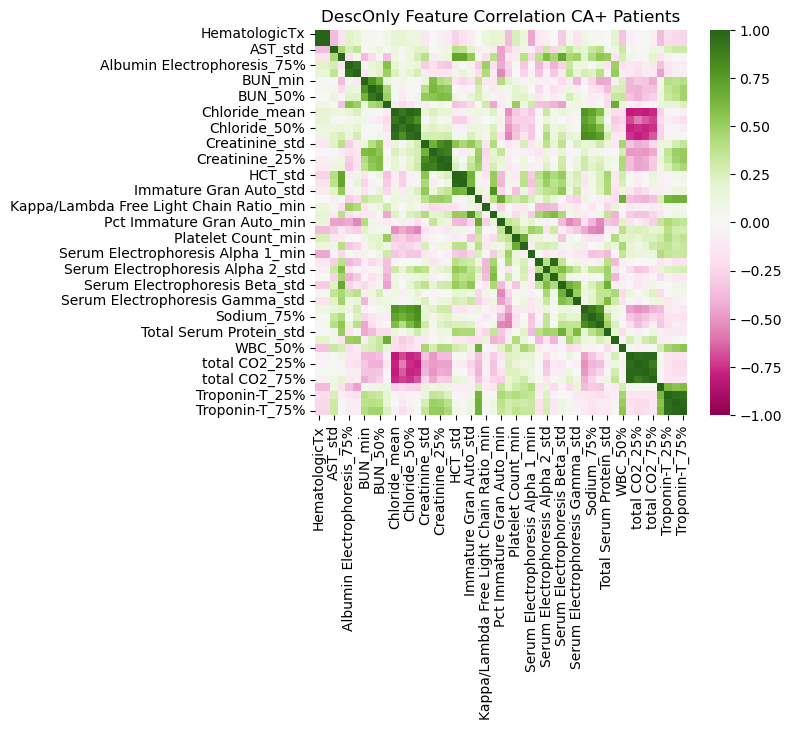

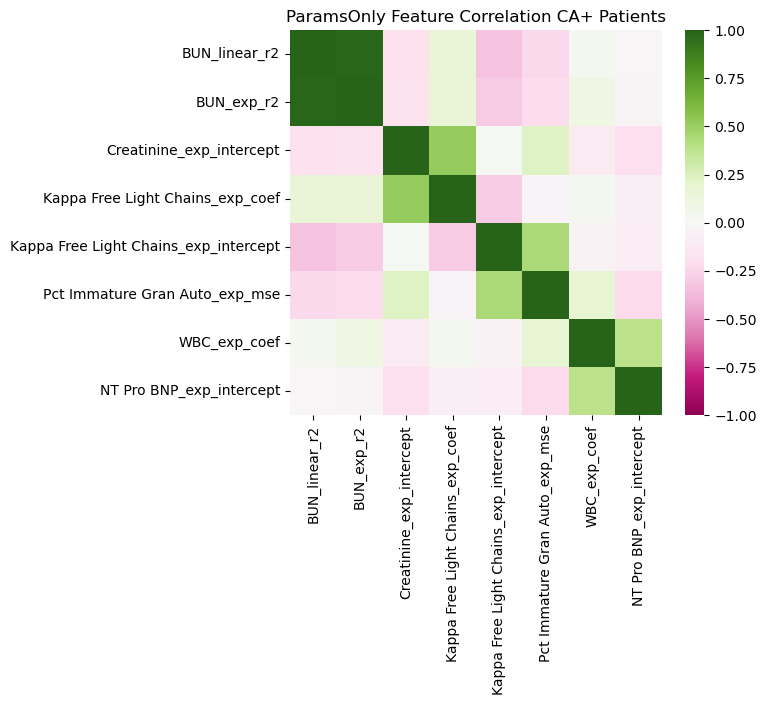

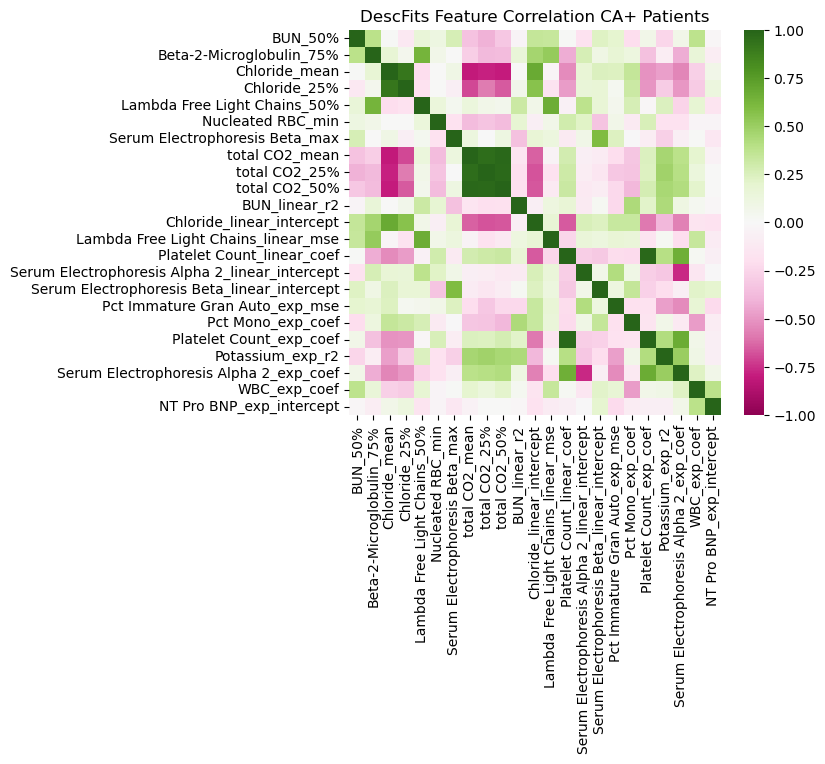

In [16]:
# correlation map of only the selected features
#CA+ patients only
for model in modelNames:
    fig, ax = plt.subplots(figsize= (6,5))
    feature_corr = dict_dataimport_positive[model].iloc[:,1:].corr(method = 'spearman')
    sns.heatmap(feature_corr, cmap = "PiYG", vmin =-1, vmax = 1, center = 0, annot = False, ax= ax)
    plt.title(str(model)+ " Feature Correlation CA+ Patients")

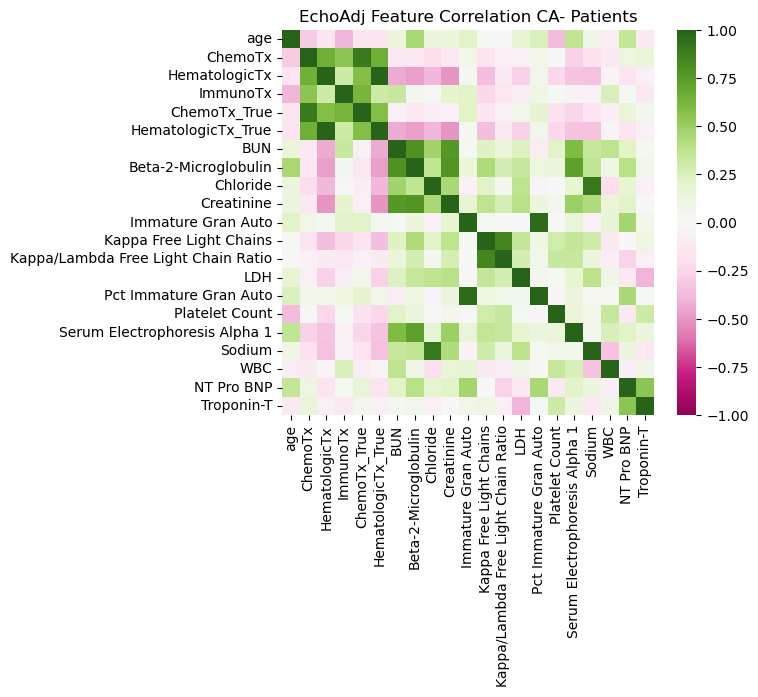

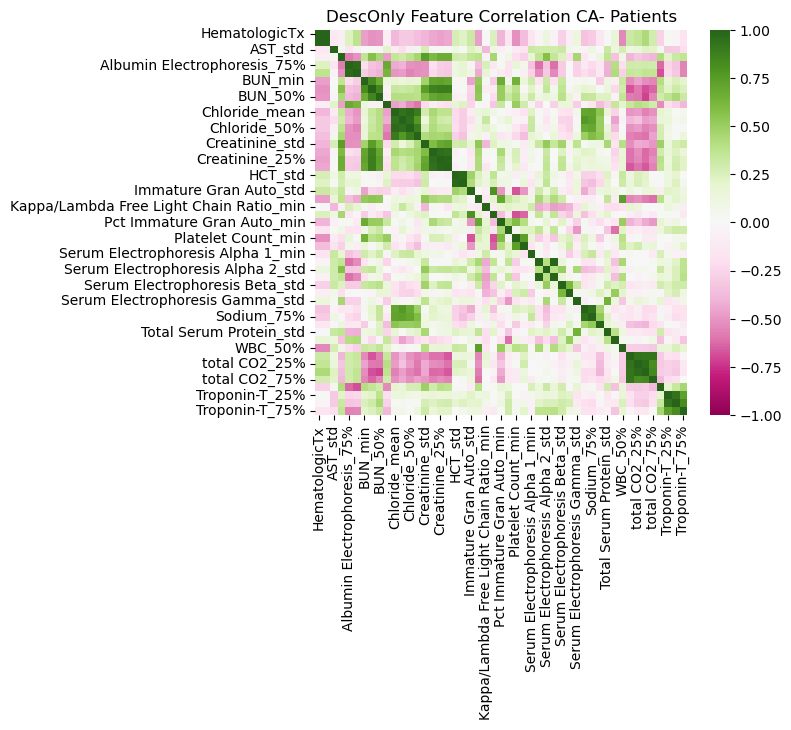

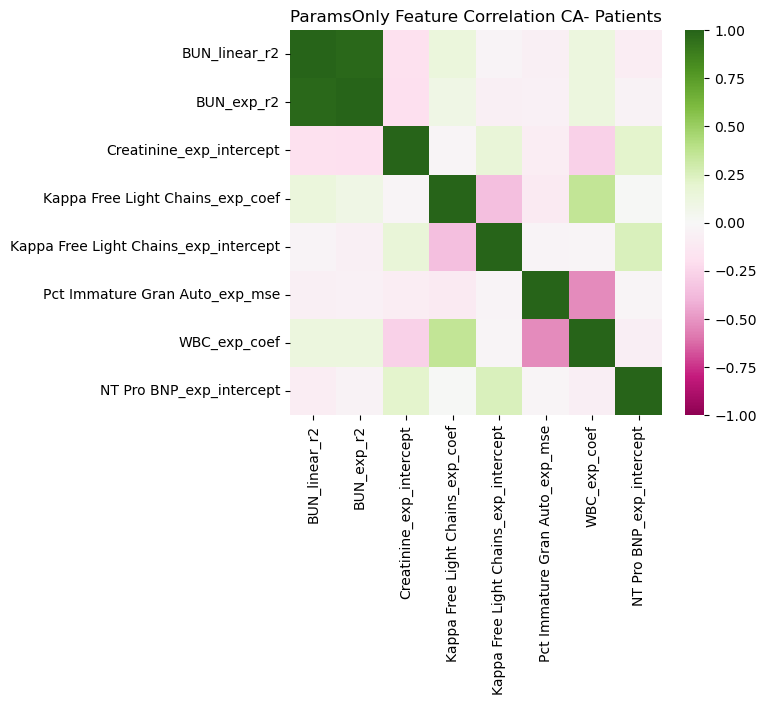

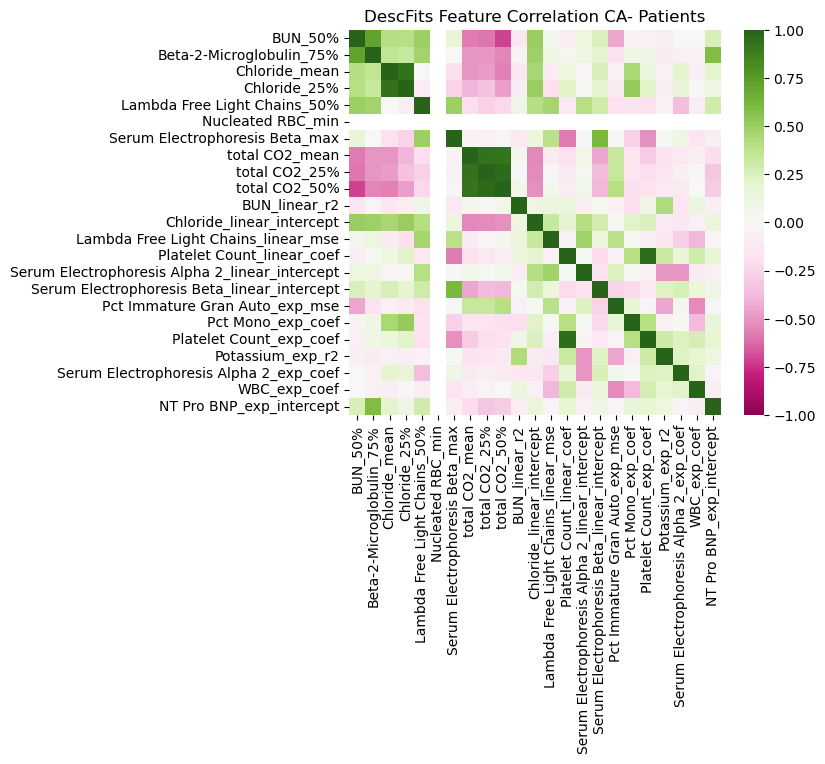

In [17]:
# correlation map of only the selected features
#CA- patients only
for model in modelNames:
    fig, ax = plt.subplots(figsize= (6,5))
    feature_corr = dict_dataimport_negative[model].iloc[:,1:].corr(method = 'spearman')
    sns.heatmap(feature_corr, cmap = "PiYG", vmin =-1, vmax = 1, center = 0, annot = False, ax= ax)
    plt.title(str(model)+ " Feature Correlation CA- Patients")

# visualization second round feature selection

## frequency of features

<Axes: >

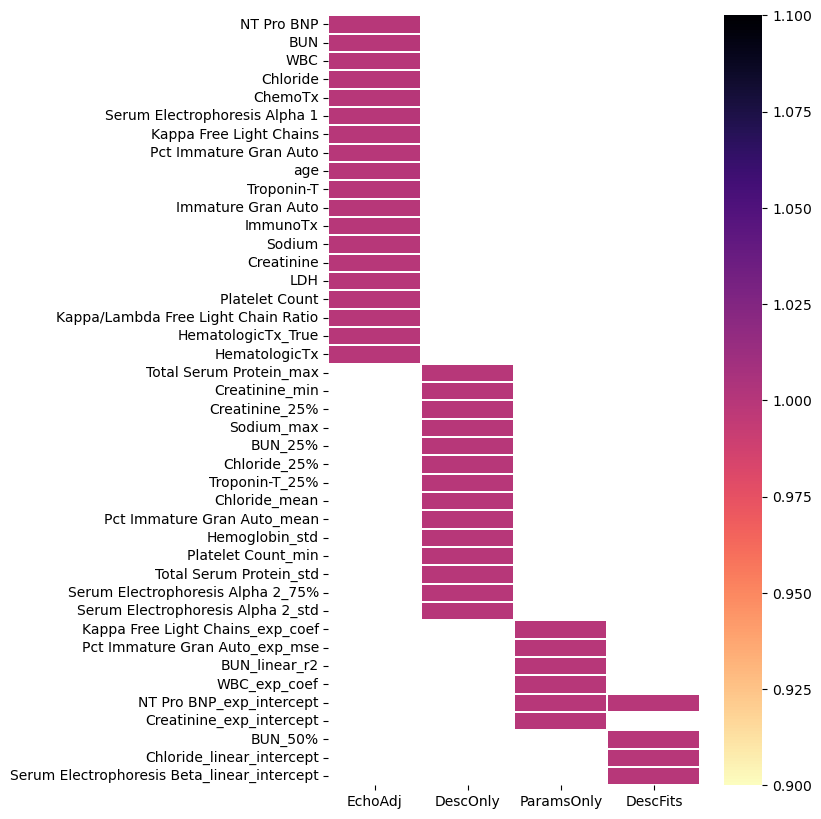

In [18]:
#plotting heatmap for feature frequency across models
fig, ax = plt.subplots(figsize = (6,10))
sns.heatmap(count_selectedFeats_second, cmap = cmap, ax = ax, linewidths = 0.1)

<Axes: >

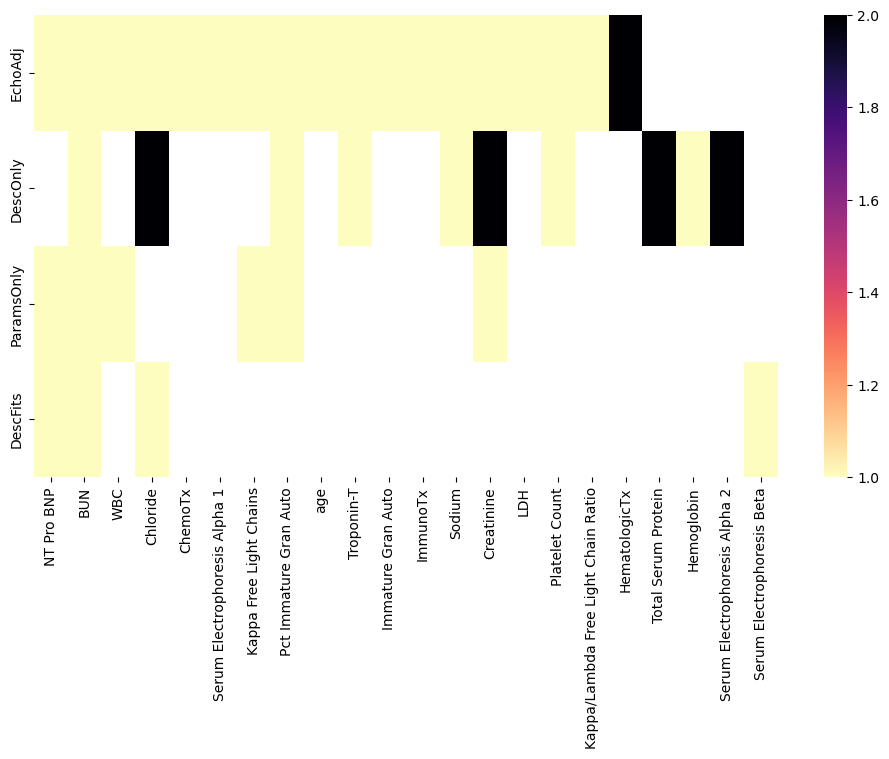

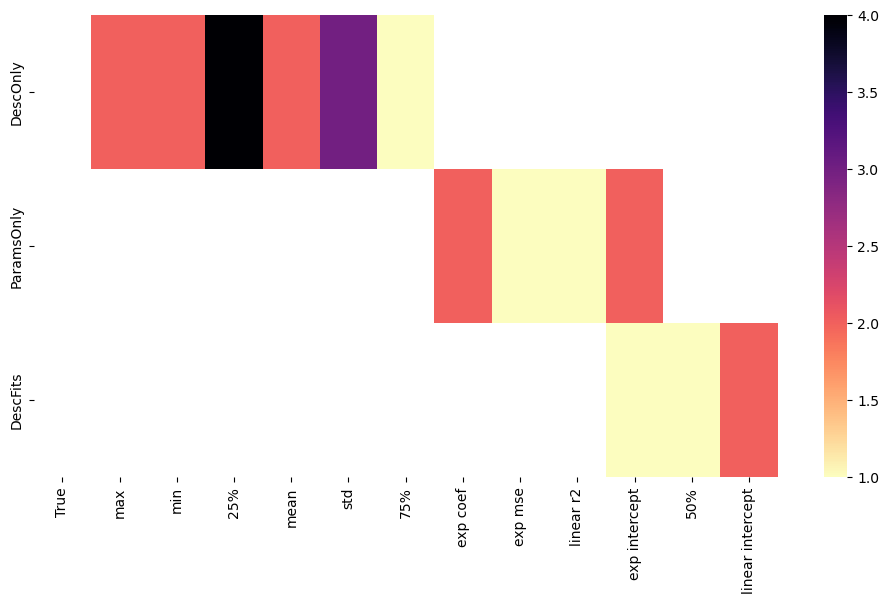

In [19]:
fig, ax = plt.subplots(figsize = (12,6))
sns.heatmap(count_orgData_second.T, ax=ax, cmap = cmap)

fig, ax2 = plt.subplots(figsize = (12,6))
sns.heatmap(count_transforms_second.iloc[1:].T.iloc[1:], ax=ax2, cmap = cmap)

Text(0.5, 1.0, 'Frequency of Data Characteristic')

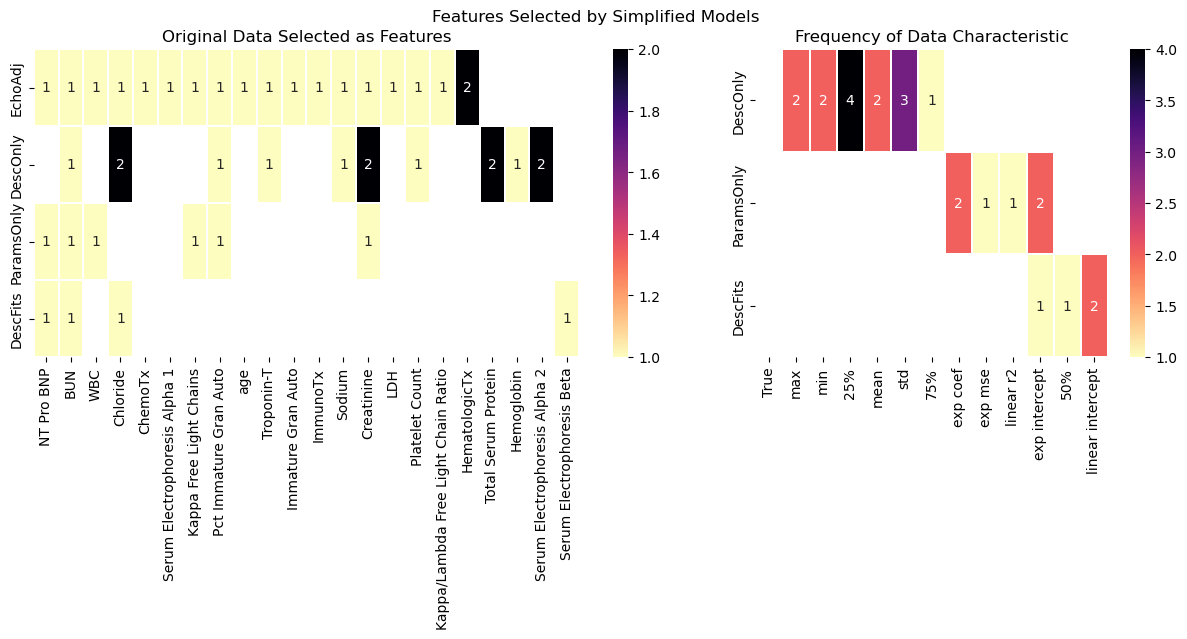

In [20]:
fig= plt.figure(figsize = (15,4))
fig.suptitle("Features Selected by Simplified Models")
ax1 = plt.subplot2grid((1, 5), (0,0), colspan = 3)
sns.heatmap(count_orgData_second.T, ax=ax1, cmap = cmap, linewidths=0.1, annot=True)
ax1.set_title("Original Data Selected as Features")
ax2 = plt.subplot2grid((1, 5), (0,3), colspan=2)
sns.heatmap(count_transforms_second.iloc[1:].T.iloc[1:], ax=ax2, cmap = cmap, linewidths=0.1, annot= True)
ax2.set_title("Frequency of Data Characteristic")

## correlation plots

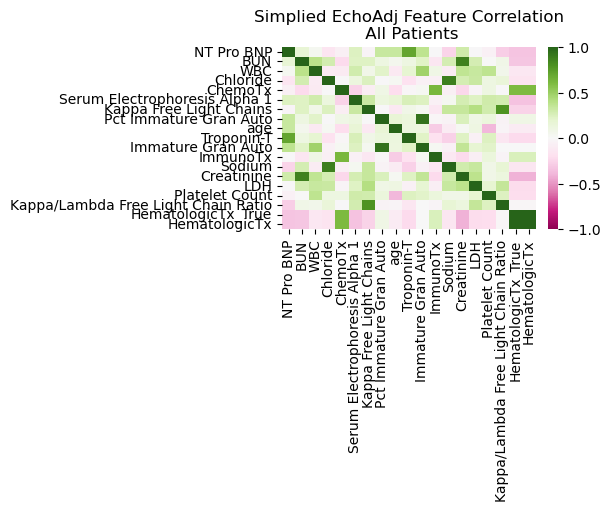

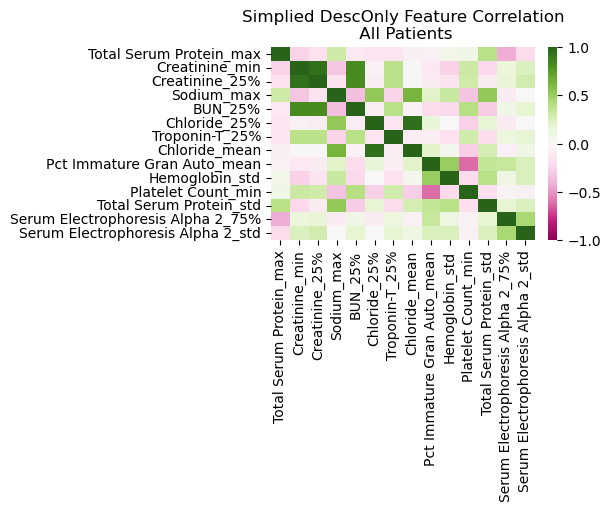

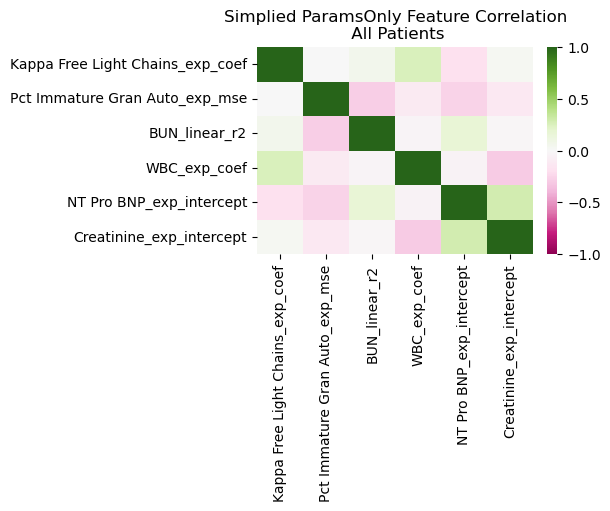

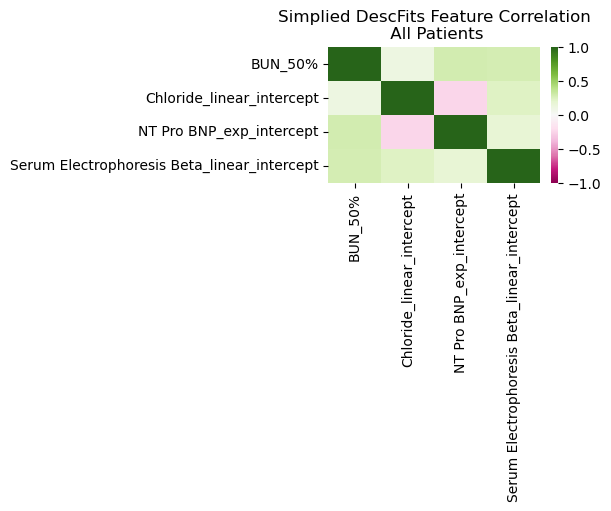

In [21]:
for model in modelNames:
    fig, ax1= plt.subplots(figsize = (6,5), layout ='constrained')
    ax1.set_title("Simplied "+ str(model) + " Feature Correlation"+ "\n All Patients")
    # ax1 = plt.subplot2grid((1, 3), (0,0))
    feature_corr = dict_dataimport_all_second[model].iloc[:,1:].corr(method = 'spearman')
    sns.heatmap(feature_corr, cmap = "PiYG", vmin =-1, vmax = 1, center = 0, annot = False, ax= ax1)
    # ax1.set_title("All Patients")

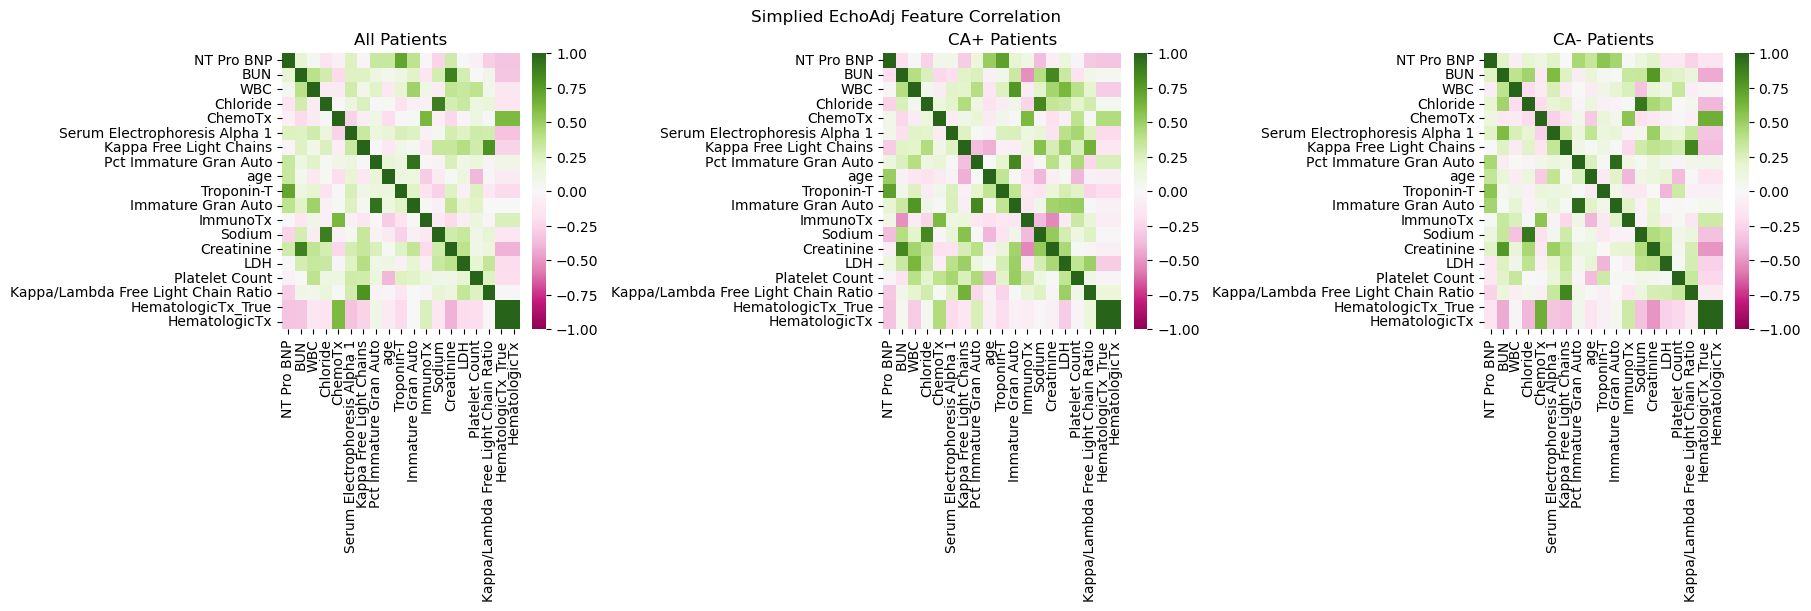

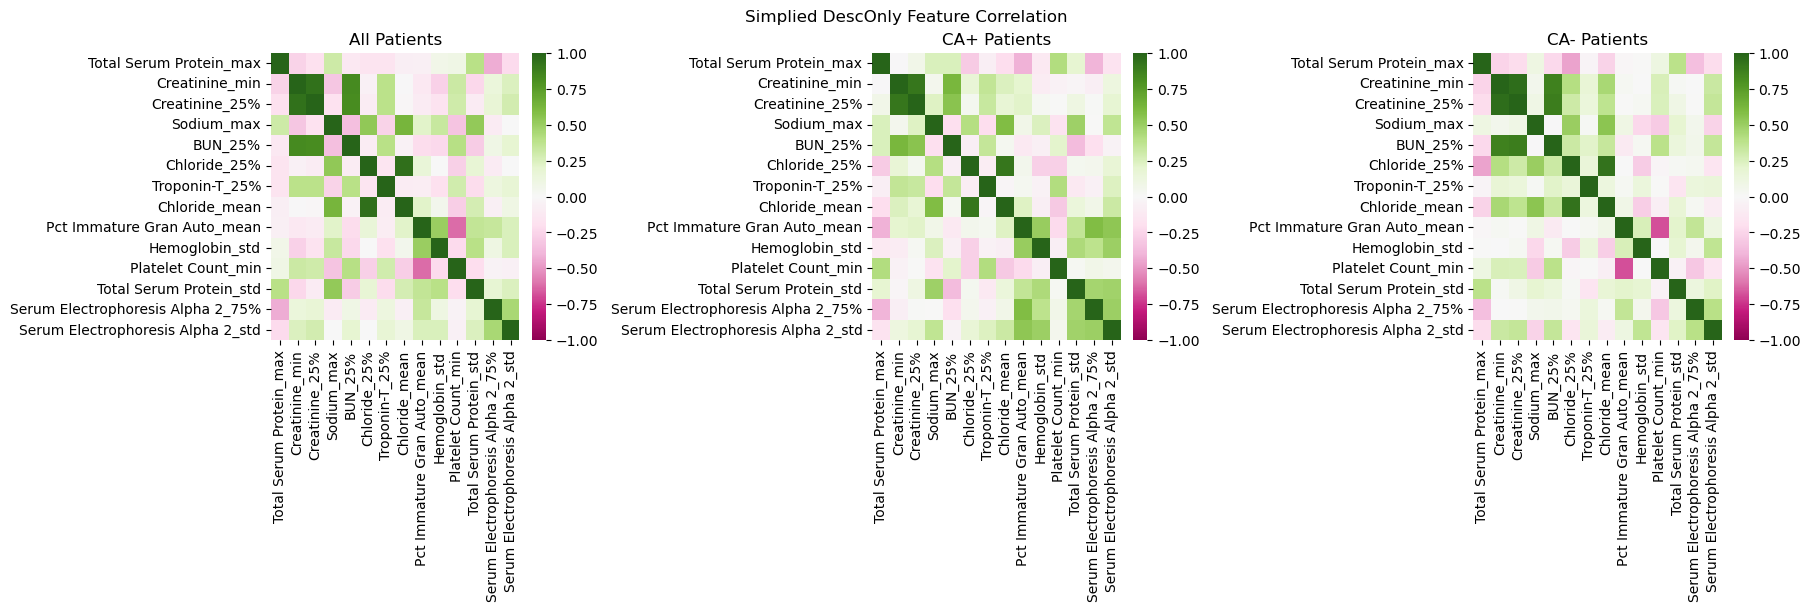

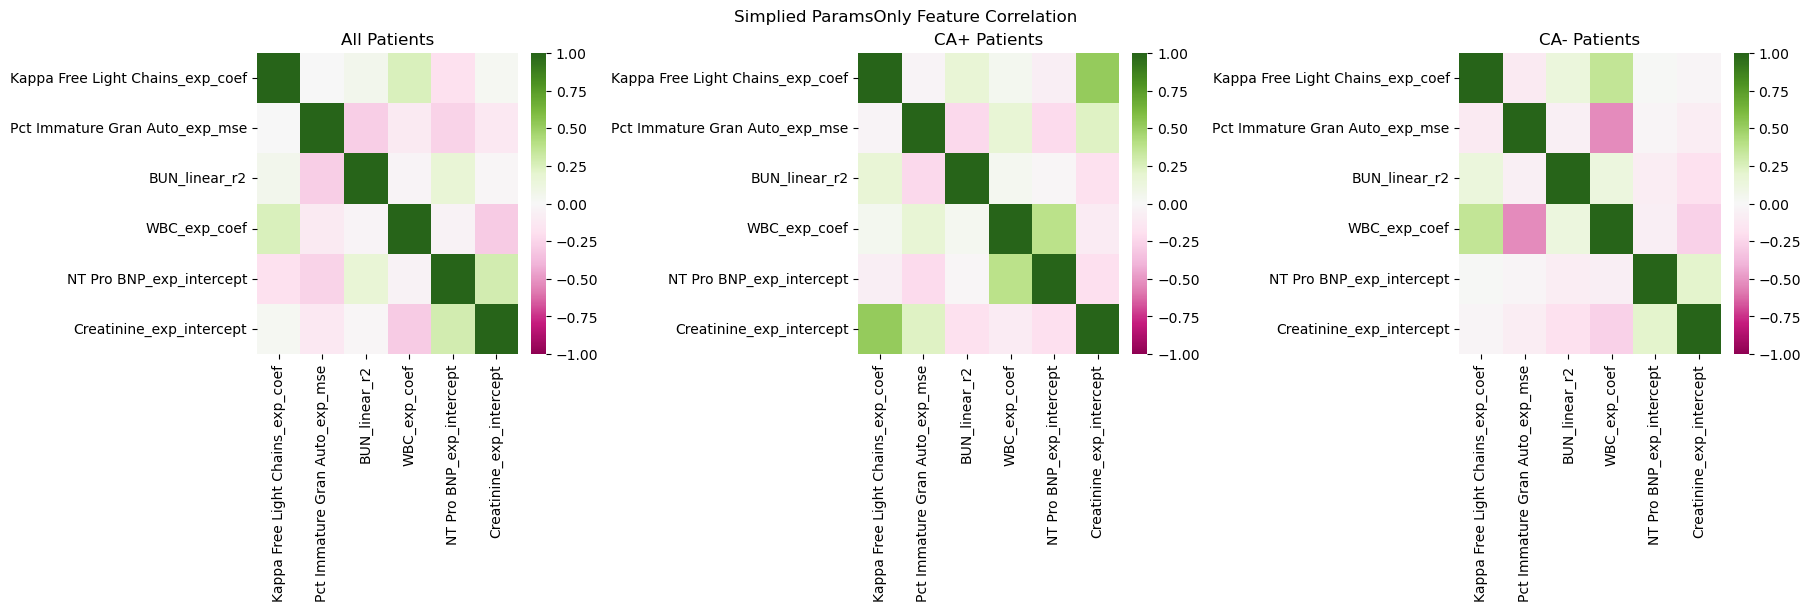

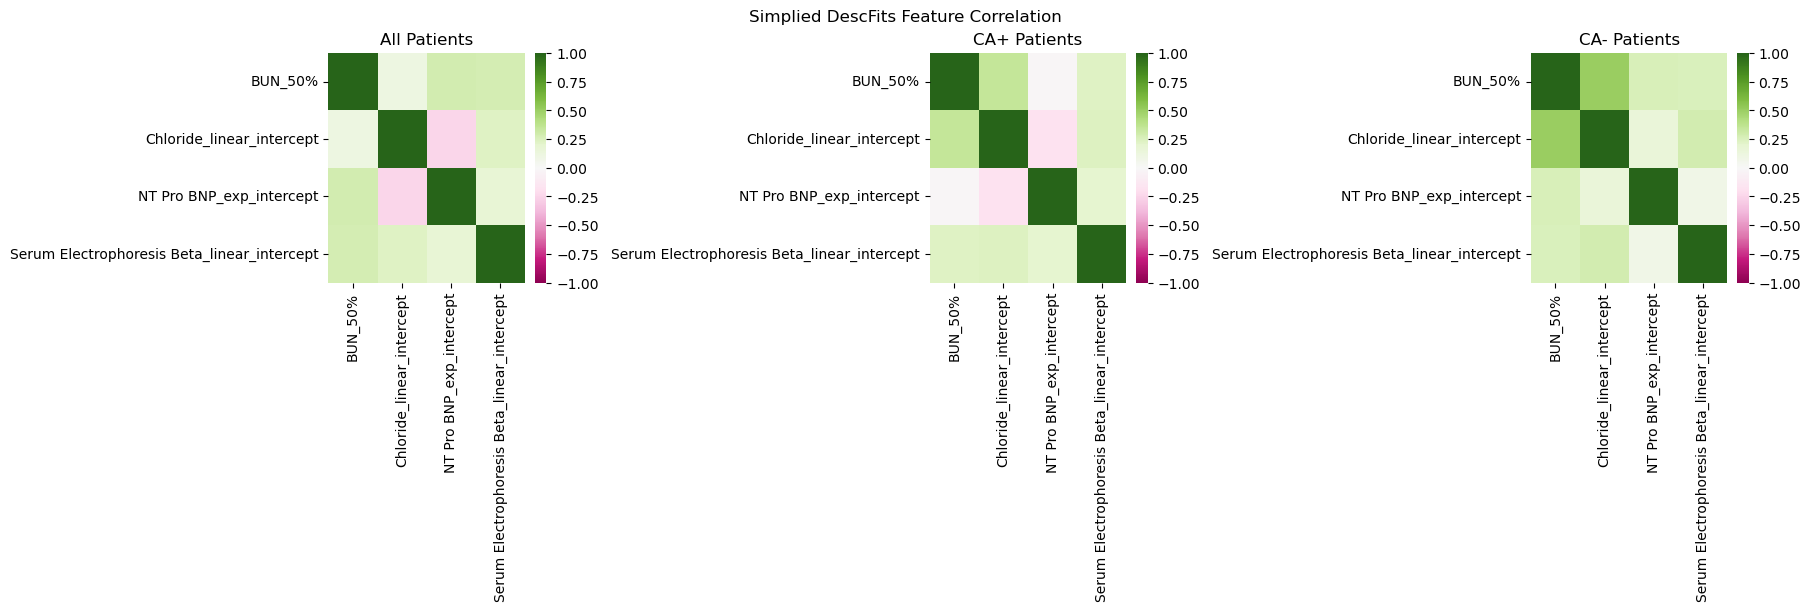

In [22]:
# correlation map of only the selected features
for model in modelNames:
    fig= plt.figure(figsize = (18,6), layout ='constrained')
    fig.suptitle("Simplied "+ str(model) + " Feature Correlation")
    ax1 = plt.subplot2grid((1, 3), (0,0))
    feature_corr = dict_dataimport_all_second[model].iloc[:,1:].corr(method = 'spearman')
    sns.heatmap(feature_corr, cmap = "PiYG", vmin =-1, vmax = 1, center = 0, annot = False, ax= ax1)
    ax1.set_title("All Patients")

    ax2 = plt.subplot2grid((1, 3), (0,1))
    feature_corr = dict_dataimport_positive_second[model].iloc[:,1:].corr(method = 'spearman')
    sns.heatmap(feature_corr, cmap = "PiYG", vmin =-1, vmax = 1, center = 0, annot = False, ax= ax2)
    ax2.set_title("CA+ Patients")

    ax3 = plt.subplot2grid((1, 3), (0,2))
    feature_corr = dict_dataimport_negative_second[model].iloc[:,1:].corr(method = 'spearman')
    sns.heatmap(feature_corr, cmap = "PiYG", vmin =-1, vmax = 1, center = 0, annot = False, ax= ax3)
    ax3.set_title("CA- Patients")

    

